# ODE Solver Comparison — 1D Helmholtz Equation

Compare five solvers available through `SOLVER_DICT` in `main.py`:

| Solver | Family | Order | Stages | Adaptive |
|---|---|---|---|---|
| `Heun` | Explicit RK | 2 | 2 | yes (embedded) |
| `Tsit5` | Explicit RK (FSAL) | 5 | 7 | yes |
| `Dopri5` | Explicit RK (FSAL) | 5 | 7 | yes |
| `KenCarp4` | IMEX ARK | 4 | 6 | yes |
| `SemiImplicitEuler` | Symplectic | 1 | 2 | no |

**IMEX split used here** (TE equation as example):
$$
\underbrace{\begin{pmatrix} E \\ E' \end{pmatrix}' = \begin{pmatrix} E' \\ 0 \end{pmatrix}}_{\text{explicit (kinematic)}}
+ \underbrace{\begin{pmatrix} 0 \\ -k_\text{eff}^2 E \end{pmatrix}}_{\text{implicit (stiff potential)}}
$$
The potential term $k_\text{eff}^2(z) = k_0^2\varepsilon(z) - k_x^2$ is large for high frequency and benefits from implicit treatment.

In [1]:
import jax
jax.config.update('jax_enable_x64', True)
try:
    jax.config.update('jax_platform_name', 'gpu')
    _ = jax.devices('gpu')
    print('Using GPU:', jax.devices('gpu'), flush=True)
except RuntimeError:
    jax.config.update('jax_platform_name', 'cpu')
    print('GPU not available, using CPU.', flush=True)

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from main import (
    HelmholtzSolver1D, make_kz, SOLVER_DICT,
    build_interp_arrays, sweep_ode,
)

Using GPU: [CudaDevice(id=0), CudaDevice(id=1)]
Using GPU: [CudaDevice(id=0), CudaDevice(id=1)]
2
[CudaDevice(id=0), CudaDevice(id=1)]


## Butcher Tableaux

Coefficients are read directly from the diffrax solver class attributes.

**Colour key:**
- Yellow column: $c_i$ nodes
- Teal cell: diagonal entry $a_{ii}$ (nonzero only for implicit/IMEX methods)
- Blue cell: nonzero lower-triangular $a_{ij}$
- Green row: solution weights $b_i$
- Orange row: embedded error weights $b^*_i$

In [2]:
# ── Helper: reconstruct full A matrix from diffrax a_lower tuple ─────────────
def build_A(a_lower, s, a_diagonal=None):
    A = np.zeros((s, s), dtype=float)
    for i, row in enumerate(a_lower):
        A[i + 1, :len(row)] = np.asarray(row, dtype=float)
    if a_diagonal is not None:
        for i, d in enumerate(a_diagonal):
            A[i, i] = float(d)
    return A

# ── Explicit Butcher data from diffrax ───────────────────────────────────────
# Heun (s=2)
c_heun = np.array([0.0, 1.0])
A_heun = np.array([[0., 0.], [1., 0.]])
b_heun = np.array([0.5, 0.5])
berr_heun = np.array([1.0, 0.0])   # 1st-order embedded

# Tsit5 (FSAL, s=7)
from diffrax import Tsit5 as _Tsit5, Dopri5 as _Dopri5
tab_t = _Tsit5.tableau
c_tsit5 = np.concatenate([[0.0], np.asarray(tab_t.c)])
A_tsit5 = build_A(tab_t.a_lower, 7)
b_tsit5 = np.asarray(tab_t.b_sol)
b_tsit5_err = np.asarray(tab_t.b_error) if tab_t.b_error is not None else None

# Dopri5 (FSAL, s=7)
tab_d = _Dopri5.tableau
c_dopri5 = np.concatenate([[0.0], np.asarray(tab_d.c)])
A_dopri5 = build_A(tab_d.a_lower, 7)
b_dopri5 = np.asarray(tab_d.b_sol)
b_dopri5_err = np.asarray(tab_d.b_error) if tab_d.b_error is not None else None

# KenCarp4 (IMEX ARK, s=6) — load explicit + implicit tableaux
from diffrax._solver.kencarp4 import (
    _explicit_tableau as _kc4_exp,
    _implicit_tableau as _kc4_imp,
    _c as _kc4_c,
    _b_sol as _kc4_b,
    _γ as _kc4_gamma,
)
c_kc4    = np.concatenate([[0.0], np.asarray(_kc4_c)])
A_kc4_e  = build_A(_kc4_exp.a_lower, 6)
A_kc4_i  = build_A(_kc4_imp.a_lower, 6, _kc4_imp.a_diagonal)
b_kc4    = np.asarray(_kc4_b)

# SemiImplicitEuler — symplectic Euler pair
# pos update: pos_new = pos + h * vel_old  (explicit Euler on position)
# vel update: vel_new = vel + h * force(pos_new)  (implicit-ish on velocity)
c_sie   = np.array([0.0, 1.0])
A_sie_e = np.array([[0., 0.], [1., 0.]])   # position stage uses old velocity
A_sie_i = np.array([[0., 0.], [1., 0.]])   # velocity stage uses updated position
b_sie   = np.array([1.0, 0.0])             # position weight (velocity weight implicit)

print('All Butcher data loaded.')

All Butcher data loaded.


<>:24: SyntaxWarning: invalid escape sequence '\ '
<>:24: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_3288548/3712690585.py:24: SyntaxWarning: invalid escape sequence '\ '
  col_labels = ['c \ k'] + [f'k{i+1}' for i in range(s)]


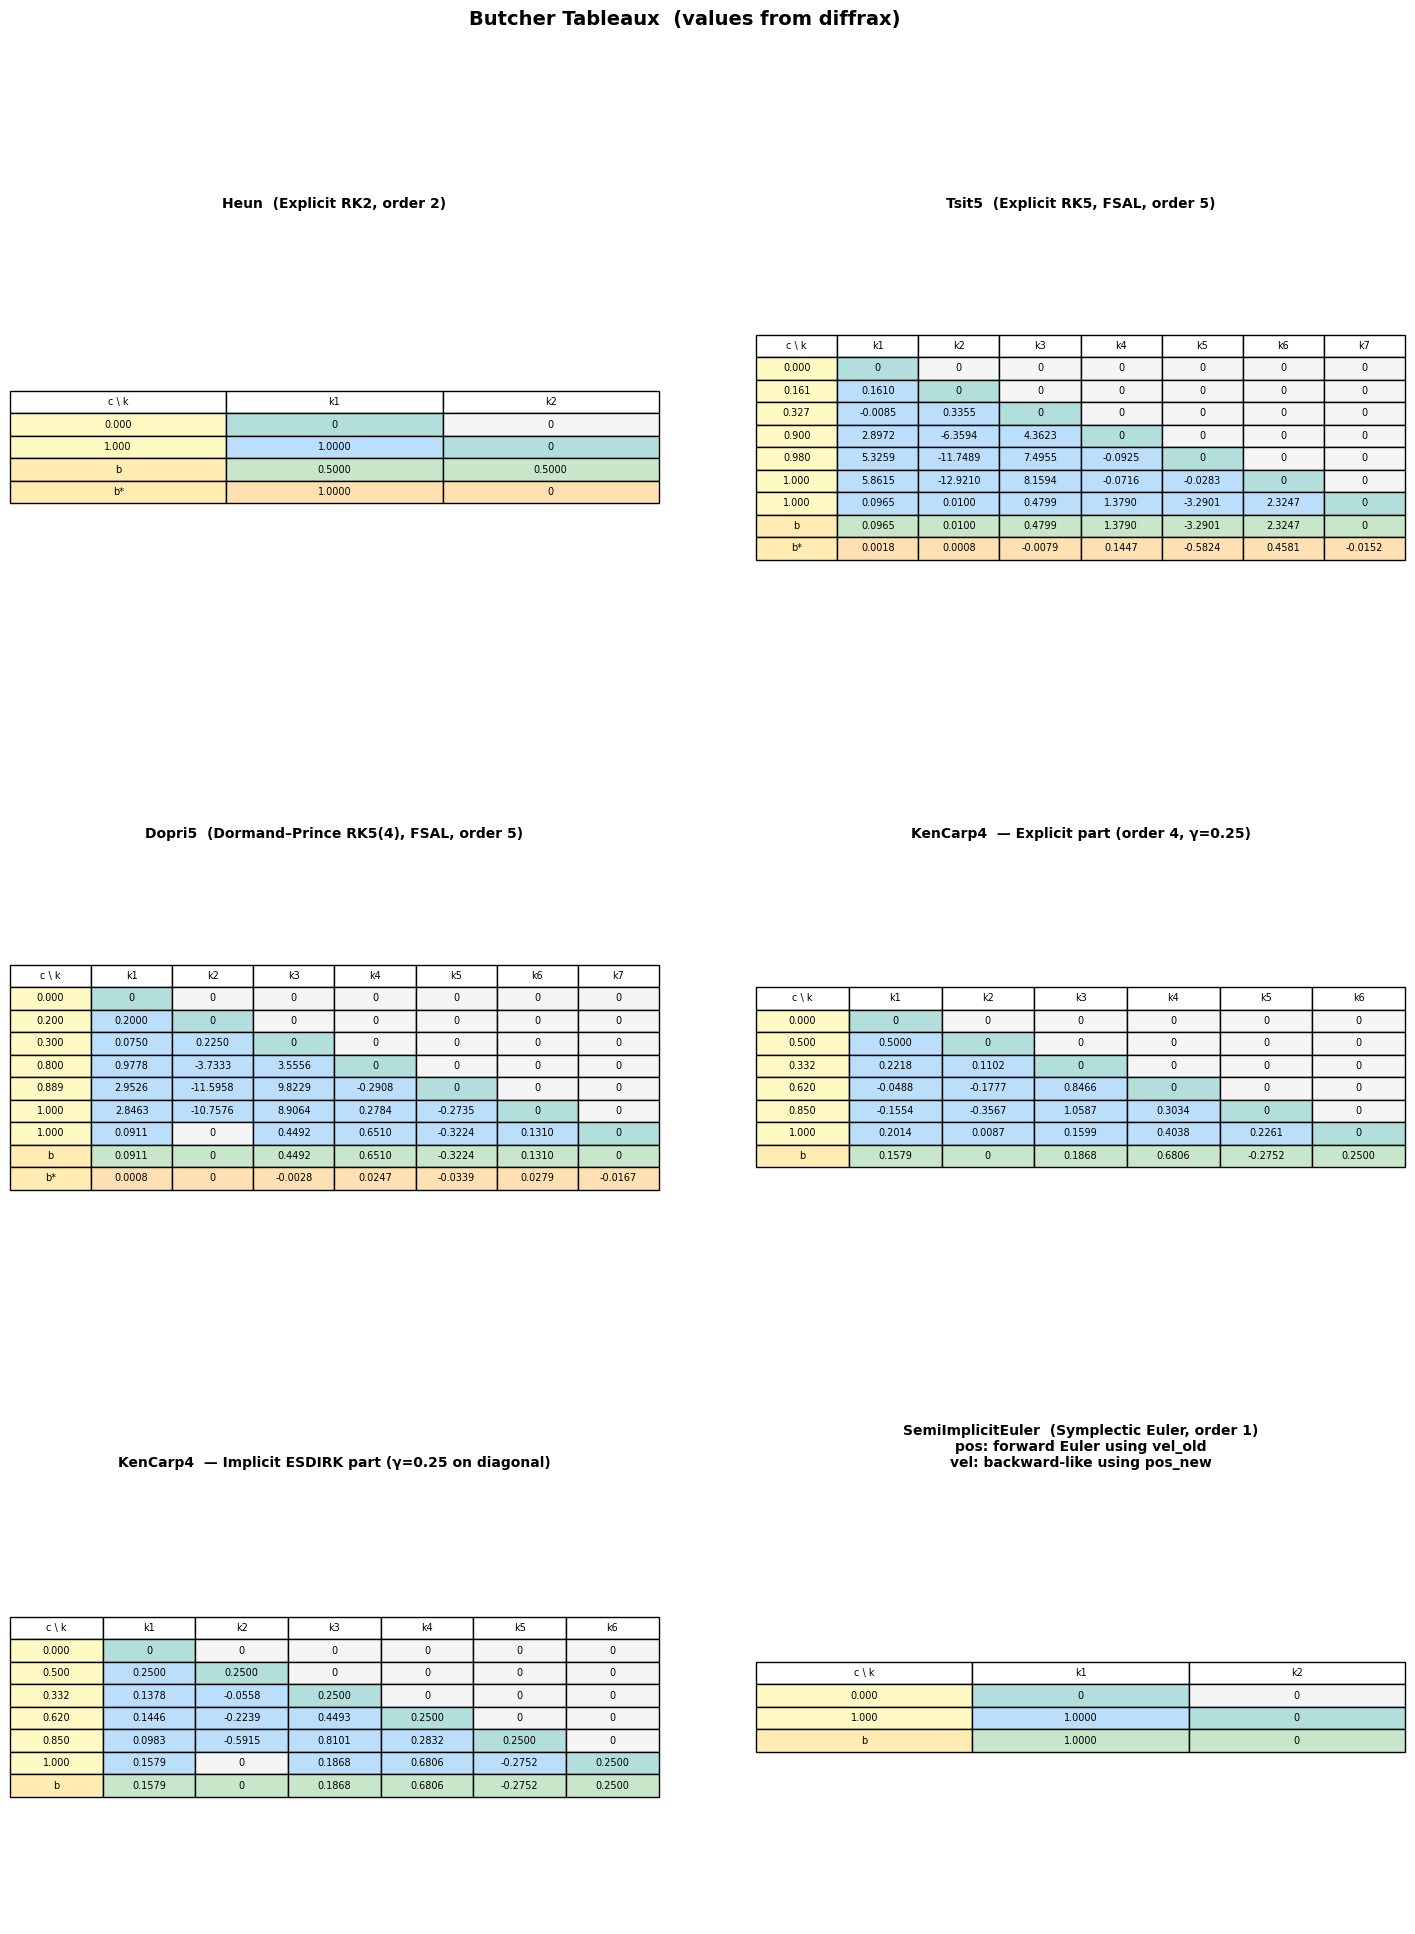

Saved butcher_tableaux.png


In [3]:
def draw_butcher(ax, c, A, b, b_err=None, title='', fmt='.4f'):
    """Render a Butcher tableau on ax as a coloured matplotlib table."""
    s = len(c)

    def fval(v):
        return '0' if abs(v) < 5e-10 else f'{v:{fmt}}'

    rows, colors = [], []
    for i in range(s):
        row = [f'{c[i]:.3f}'] + [fval(A[i, j]) for j in range(s)]
        rows.append(row)
        def cell_color(ii, jj):   # ii = row, jj = col in A (0-indexed)
            if jj == ii:   return '#B2DFDB'      # diagonal (IMEX)
            if abs(A[ii, jj]) > 5e-10: return '#BBDEFB'  # nonzero
            return '#F5F5F5'
        colors.append(['#FFF9C4'] + [cell_color(i, j) for j in range(s)])

    rows.append(['b'] + [fval(v) for v in b])
    colors.append(['#FFECB3'] + ['#C8E6C9'] * s)
    if b_err is not None:
        rows.append(['b*'] + [fval(v) for v in b_err])
        colors.append(['#FFECB3'] + ['#FFE0B2'] * s)

    col_labels = ['c \ k'] + [f'k{i+1}' for i in range(s)]
    ax.axis('off')
    tbl = ax.table(
        cellText=rows, colLabels=col_labels,
        cellColours=colors, cellLoc='center', loc='center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(7)
    tbl.scale(1.0, 1.35)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=16)


# ── Row 1: Heun, Tsit5 (columns 1-4, 5-7 merged)
fig = plt.figure(figsize=(18, 22))
gs  = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.15)

ax1 = fig.add_subplot(gs[0, 0])
draw_butcher(ax1, c_heun, A_heun, b_heun, berr_heun,
             title='Heun  (Explicit RK2, order 2)')

ax2 = fig.add_subplot(gs[0, 1])
draw_butcher(ax2, c_tsit5, A_tsit5, b_tsit5, b_tsit5_err,
             title='Tsit5  (Explicit RK5, FSAL, order 5)')

ax3 = fig.add_subplot(gs[1, 0])
draw_butcher(ax3, c_dopri5, A_dopri5, b_dopri5, b_dopri5_err,
             title='Dopri5  (Dormand–Prince RK5(4), FSAL, order 5)')

ax4 = fig.add_subplot(gs[1, 1])
draw_butcher(ax4, c_kc4, A_kc4_e, b_kc4, title=
             f'KenCarp4  — Explicit part (order 4, γ={_kc4_gamma})')

ax5 = fig.add_subplot(gs[2, 0])
draw_butcher(ax5, c_kc4, A_kc4_i, b_kc4, title=
             f'KenCarp4  — Implicit ESDIRK part (γ={_kc4_gamma} on diagonal)')

ax6 = fig.add_subplot(gs[2, 1])
draw_butcher(ax6, c_sie, A_sie_e, b_sie,
             title='SemiImplicitEuler  (Symplectic Euler, order 1)\n'
                   'pos: forward Euler using vel_old\n'
                   'vel: backward-like using pos_new')

fig.suptitle('Butcher Tableaux  (values from diffrax)',
             fontsize=14, fontweight='bold', y=0.98)
plt.savefig('butcher_tableaux.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved butcher_tableaux.png')

## Convergence vs `res_trans` (cells per λ₀)

**Problem:** linear ε profile, θ=30°, TE (S), same as `helmholtz_test.ipynb` Test 4.

**Reference:** Dopri5 adaptive with `res_trans=8000/λ₀` (width=1λ₀ → n_trans=8000) and `rtol=1e-12`.

**res_trans** = cells per λ₀ inside the transition layer [z₁, z₂].  
For this setup (width=1λ₀, λ₀=1): `n_trans = res_trans` numerically.  
Physical step size: $h = \lambda_0 / \text{res\_trans}$.  
**Auto-default** = $10 \times \max|\varepsilon_r| = 40/\lambda_0$ (marked with green line in plots).

**Fixed-step sweep** (`fixed_step=True`): each solver uses exactly `n_trans=res_trans` steps.  
This reveals the theoretical order: log-log slope ≈ −p in error vs res_trans.

> **Note:** `KenCarp4` is IMEX — `fixed_step=True` is overridden; its order-4 convergence is still visible.  
> `SemiImplicitEuler` has no error estimator and is always fixed-step (order 1).

**Adaptive sweep** (`fixed_step=False`): `res_trans` is only a step-size hint; PID controller adapts.  
Dopri5 and Tsit5 reach machine precision; Heun saturates earlier.

In [4]:
lambda0 = 1.0
z1, z2  = -0.5, 0.5
eps1, eps2 = 1.0, 4.0

def eps_linear(z):
    if z <= z1: return eps1
    if z >= z2: return eps2
    return eps1 + (eps2 - eps1) * (z - z1) / (z2 - z1)

theta, pol = 30.0, 'S'
solver_ref = HelmholtzSolver1D(eps_linear, z1, z2,
                                theta_deg=theta, pol=pol, lambda0=lambda0)

# High-accuracy reference: res_trans=8000/λ₀, width=1λ₀ → n_trans=8000
ref = solver_ref.solve_ode(res_trans=8000,
                            solver_name='Dopri5', rtol=1e-12, atol=1e-14)
r_ref = ref['r']
print(f'Reference r = {r_ref:.8f}  |r|² = {abs(r_ref)**2:.8f}')

HelmholtzSolver1D: pol=S, θ=30.0°, λ₀=1.0, ε₁=1+0j, ε₂=4+0j, kz1=5.441+0j, kz2=12.17+0j
  → ODE res_trans=8000.00/λ₀ → n_trans=8000
[ODE/Dopri5] r = 0.0685∠110.7°, t = 0.6672∠-168.3°
Reference r = -0.02425199+0.06403268j  |r|² = 0.00468834


In [5]:
# ── Fixed-step convergence vs res_trans ──────────────────────────────────────
# res_trans = cells per λ₀ in the transition layer.
# For this setup (width=1λ₀, lambda0=1): n_trans = res_trans numerically.
res_list  = [25, 50, 100, 200, 400, 800, 1600, 3200]
solvers   = list(SOLVER_DICT.keys())
colors_cv = {'Dopri5': '#1565C0', 'Tsit5': '#2E7D32',
             'Heun': '#E65100', 'KenCarp4': '#6A1B9A',
             'SemiImplicitEuler': '#B71C1C'}
markers   = {'Dopri5': 'o', 'Tsit5': 's', 'Heun': '^',
             'KenCarp4': 'D', 'SemiImplicitEuler': 'v'}

err_fixed = {s: [] for s in solvers}

for res in res_list:
    print(f'res_trans={res}/λ₀:', end='  ', flush=True)
    for sname in solvers:
        try:
            result = solver_ref.solve_ode(
                res_trans=res,
                solver_name=sname, fixed_step=True,
            )
            err_fixed[sname].append(abs(result['r'] - r_ref))
            print(f'{sname[:4]}={err_fixed[sname][-1]:.2e}', end='  ', flush=True)
        except Exception as ex:
            err_fixed[sname].append(np.nan)
            print(f'{sname[:4]}=ERR({ex})', end='  ', flush=True)
    print()

print('Done.')

res_trans=25/λ₀:    → ODE res_trans=25.00/λ₀ → n_trans=25
[ODE/Dopri5] r = 0.0685∠110.7°, t = 0.6672∠-168.3°
Dopr=3.47e-07    → ODE res_trans=25.00/λ₀ → n_trans=25
[ODE/Tsit5] r = 0.0685∠110.7°, t = 0.6672∠-168.3°
Tsit=1.61e-07    → ODE res_trans=25.00/λ₀ → n_trans=25
[ODE/Heun] r = 0.0702∠113.4°, t = 0.6207∠179.0°
Heun=3.71e-03    → ODE res_trans=25.00/λ₀ → n_trans=25
[ODE/KenCarp4] r = 0.0685∠110.7°, t = 0.6672∠-168.3°
KenC=2.46e-09    → ODE res_trans=25.00/λ₀ → n_trans=25
[ODE/SemiImplicitEuler] r = 0.1249∠104.5°, t = 0.6635∠177.0°
Semi=5.74e-02  
res_trans=50/λ₀:    → ODE res_trans=50.00/λ₀ → n_trans=50
[ODE/Dopri5] r = 0.0685∠110.7°, t = 0.6672∠-168.3°
Dopr=5.65e-09    → ODE res_trans=50.00/λ₀ → n_trans=50
[ODE/Tsit5] r = 0.0685∠110.7°, t = 0.6672∠-168.3°
Tsit=2.44e-09    → ODE res_trans=50.00/λ₀ → n_trans=50
[ODE/Heun] r = 0.0687∠111.4°, t = 0.6611∠-171.6°
Heun=8.44e-04    → ODE res_trans=50.00/λ₀ → n_trans=50
[ODE/KenCarp4] r = 0.0685∠110.7°, t = 0.6672∠-168.3°
KenC=3.46e-10    

In [6]:
# ── Adaptive convergence (res_trans as initial step hint) ────────────────────
adaptive_solvers = ['Dopri5', 'Tsit5', 'Heun']
err_adapt = {s: [] for s in adaptive_solvers}

for res in res_list:
    print(f'res_trans={res}/λ₀:', end='  ', flush=True)
    for sname in adaptive_solvers:
        result = solver_ref.solve_ode(
            res_trans=res,
            solver_name=sname, fixed_step=False,
        )
        err_adapt[sname].append(abs(result['r'] - r_ref))
        print(f'{sname[:4]}={err_adapt[sname][-1]:.2e}', end='  ', flush=True)
    print()

print('Done.')

res_trans=25/λ₀:    → ODE res_trans=25.00/λ₀ → n_trans=25
[ODE/Dopri5] r = 0.0685∠110.7°, t = 0.6672∠-168.3°
Dopr=9.27e-11    → ODE res_trans=25.00/λ₀ → n_trans=25
[ODE/Tsit5] r = 0.0685∠110.7°, t = 0.6672∠-168.3°
Tsit=1.03e-10    → ODE res_trans=25.00/λ₀ → n_trans=25
[ODE/Heun] r = 0.0685∠110.7°, t = 0.6672∠-168.3°
Heun=6.75e-10  
res_trans=50/λ₀:    → ODE res_trans=50.00/λ₀ → n_trans=50
[ODE/Dopri5] r = 0.0685∠110.7°, t = 0.6672∠-168.3°
Dopr=9.30e-11    → ODE res_trans=50.00/λ₀ → n_trans=50
[ODE/Tsit5] r = 0.0685∠110.7°, t = 0.6672∠-168.3°
Tsit=1.02e-10    → ODE res_trans=50.00/λ₀ → n_trans=50
[ODE/Heun] r = 0.0685∠110.7°, t = 0.6672∠-168.3°
Heun=6.75e-10  
res_trans=100/λ₀:    → ODE res_trans=100.00/λ₀ → n_trans=100
[ODE/Dopri5] r = 0.0685∠110.7°, t = 0.6672∠-168.3°
Dopr=9.20e-11    → ODE res_trans=100.00/λ₀ → n_trans=100
[ODE/Tsit5] r = 0.0685∠110.7°, t = 0.6672∠-168.3°
Tsit=9.99e-11    → ODE res_trans=100.00/λ₀ → n_trans=100
[ODE/Heun] r = 0.0685∠110.7°, t = 0.6672∠-168.3°
Heun=6.

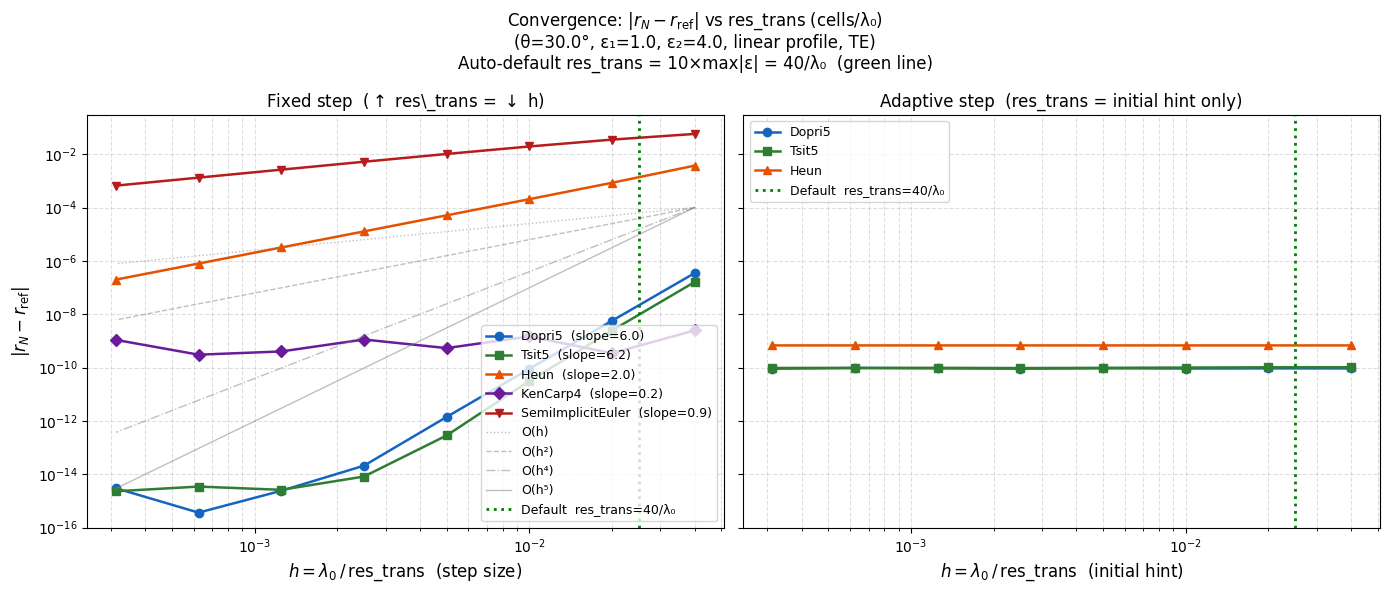

Saved solver_convergence.png


In [7]:
# h = λ₀ / res_trans = physical step size; for lambda0=1, h = 1/res_trans
h_list = lambda0 / np.array(res_list, dtype=float)
res_default = 10.0 * eps2   # = 40/λ₀ (auto-default for this profile)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.suptitle(
    r'Convergence: $|r_N - r_{\rm ref}|$ vs $\mathrm{res\_trans}$ (cells/λ₀)' + '\n'
    f'(θ={theta}°, ε₁={eps1}, ε₂={eps2}, linear profile, TE)\n'
    f'Auto-default res_trans = 10×max|ε| = {res_default:.0f}/λ₀  (green line)',
    fontsize=12)

# ── Left: fixed-step ─────────────────────────────────────────────────────────
ax = axes[0]
for sname in solvers:
    err = np.array(err_fixed[sname])
    mask = np.isfinite(err) & (err > 0)
    if mask.sum() < 2:
        continue
    h_m = h_list[mask];  e_m = err[mask]
    fit_mask = h_m > h_m.min() * 4
    if fit_mask.sum() >= 2:
        slope, intercept = np.polyfit(np.log(h_m[fit_mask]), np.log(e_m[fit_mask]), 1)
        label = f'{sname}  (slope={slope:.1f})'
    else:
        label = sname
    ax.loglog(h_m, e_m, color=colors_cv[sname], marker=markers[sname],
              ms=6, lw=1.8, label=label)

h_ref = np.array([h_list[0], h_list[-1]])
for order, ls, lbl in [(1,':', 'O(h)'), (2,'--','O(h²)'), (4,'-.','O(h⁴)'), (5,'-','O(h⁵)')]:
    ax.loglog(h_ref, 1e-4*(h_ref/h_ref[0])**order, color='gray', ls=ls, lw=1.0, alpha=0.5, label=lbl)

ax.axvline(lambda0 / res_default, color='green', ls=':', lw=2.0,
           label=f'Default  res_trans={res_default:.0f}/λ₀')
ax.set_xlabel(r'$h = \lambda_0\,/\,\mathrm{res\_trans}$  (step size)', fontsize=12)
ax.set_ylabel(r'$|r_N - r_{\rm ref}|$', fontsize=12)
ax.set_title(r'Fixed step  ($\uparrow$ res\_trans = $\downarrow$ h)', fontsize=12)
ax.legend(fontsize=9);  ax.grid(True, which='both', ls='--', alpha=0.4)

# ── Right: adaptive ──────────────────────────────────────────────────────────
ax = axes[1]
for sname in adaptive_solvers:
    err = np.array(err_adapt[sname])
    mask = np.isfinite(err) & (err > 0)
    ax.loglog(h_list[mask], err[mask],
              color=colors_cv[sname], marker=markers[sname],
              ms=6, lw=1.8, label=sname)

ax.axvline(lambda0 / res_default, color='green', ls=':', lw=2.0,
           label=f'Default  res_trans={res_default:.0f}/λ₀')
ax.set_xlabel(r'$h = \lambda_0\,/\,\mathrm{res\_trans}$  (initial hint)', fontsize=12)
ax.set_title('Adaptive step  (res_trans = initial hint only)', fontsize=12)
ax.legend(fontsize=9);  ax.grid(True, which='both', ls='--', alpha=0.4)
ax.set_ylim(bottom=1e-16)

plt.tight_layout()
plt.savefig('solver_convergence.png', dpi=120)
plt.show()
print('Saved solver_convergence.png')

  → FEM res_trans=25.00/λ₀ → n_trans=25,  res_ext=12.00/λ₀ → n_ext=24
[FEM] r = 0.1810∠91.9°, t = 0.6957∠-158.9°
  → FEM res_trans=25.00/λ₀ → n_trans=25,  res_ext=12.00/λ₀ → n_ext=24
[FEM] r = 0.0684∠111.3°, t = 0.6669∠-168.3°
res_trans=   25/λ₀: FEM-P1=1.183e-01  FEM-P2=7.180e-04
  → FEM res_trans=50.00/λ₀ → n_trans=50,  res_ext=25.00/λ₀ → n_ext=50
[FEM] r = 0.0856∠102.2°, t = 0.6722∠-166.4°
  → FEM res_trans=50.00/λ₀ → n_trans=50,  res_ext=25.00/λ₀ → n_ext=50
[FEM] r = 0.0683∠110.8°, t = 0.6672∠-168.3°
res_trans=   50/λ₀: FEM-P1=2.054e-02  FEM-P2=1.824e-04
  → FEM res_trans=100.00/λ₀ → n_trans=100,  res_ext=50.00/λ₀ → n_ext=100
[FEM] r = 0.0724∠108.5°, t = 0.6682∠-167.8°
  → FEM res_trans=100.00/λ₀ → n_trans=100,  res_ext=50.00/λ₀ → n_ext=100
[FEM] r = 0.0684∠110.8°, t = 0.6672∠-168.3°
res_trans=  100/λ₀: FEM-P1=4.731e-03  FEM-P2=4.866e-05
  → FEM res_trans=200.00/λ₀ → n_trans=200,  res_ext=100.00/λ₀ → n_ext=200
[FEM] r = 0.0694∠110.2°, t = 0.6674∠-168.2°
  → FEM res_trans=200.00/λ₀ 

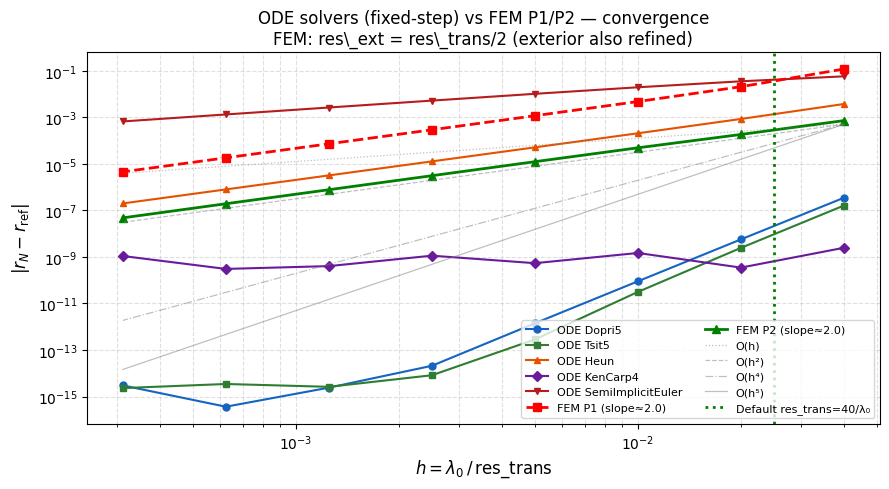

Saved solver_vs_fem_convergence.png


In [8]:
# ── FEM P1 vs P2 convergence vs res_trans (for comparison with ODE) ──────────
# res_ext = res_trans / 2 so exterior dispersion is also refined.
err_fem1, err_fem2 = [], []
for res in res_list:
    res_e = max(10, res // 2)
    rf1 = solver_ref.solve_fem(res_trans=res, res_ext=res_e, order=1)
    rf2 = solver_ref.solve_fem(res_trans=res, res_ext=res_e, order=2)
    err_fem1.append(abs(rf1['r'] - r_ref))
    err_fem2.append(abs(rf2['r'] - r_ref))
    print(f'res_trans={res:5.0f}/λ₀: FEM-P1={err_fem1[-1]:.3e}  FEM-P2={err_fem2[-1]:.3e}')

fe1 = np.array(err_fem1);  fe2 = np.array(err_fem2)
ok1 = fe1 > 1e-14;         ok2 = fe2 > 1e-14
slope1 = np.polyfit(np.log(h_list[ok1][-4:]), np.log(fe1[ok1][-4:]), 1)[0] if ok1.sum() >= 4 else 0
slope2 = np.polyfit(np.log(h_list[ok2][-4:]), np.log(fe2[ok2][-4:]), 1)[0] if ok2.sum() >= 4 else 0

fig, ax = plt.subplots(figsize=(9, 5))
for sname in ['Dopri5', 'Tsit5', 'Heun', 'KenCarp4', 'SemiImplicitEuler']:
    err = np.array(err_fixed[sname])
    mask = np.isfinite(err) & (err > 0)
    if mask.sum() >= 2:
        ax.loglog(h_list[mask], err[mask],
                  color=colors_cv[sname], marker=markers[sname],
                  ms=5, lw=1.5, label=f'ODE {sname}')

ax.loglog(h_list[ok1], fe1[ok1], 'rs--', ms=6, lw=2,
          label=f'FEM P1 (slope≈{slope1:.1f})')
ax.loglog(h_list[ok2], fe2[ok2], 'g^-',  ms=6, lw=2,
          label=f'FEM P2 (slope≈{slope2:.1f})')

for order, ls, lbl in [(1,':', 'O(h)'), (2,'--','O(h²)'), (4,'-.','O(h⁴)'), (5,'-','O(h⁵)')]:
    ax.loglog(h_list[[0,-1]], 5e-4*(np.array([h_list[0],h_list[-1]])/h_list[0])**order,
              color='gray', ls=ls, lw=0.9, alpha=0.5, label=lbl)

ax.axvline(lambda0 / (10.0 * eps2), color='green', ls=':', lw=2.0,
           label=f'Default res_trans={10*eps2:.0f}/λ₀')
ax.set_xlabel(r'$h = \lambda_0\,/\,\mathrm{res\_trans}$', fontsize=12)
ax.set_ylabel(r'$|r_N - r_{\rm ref}|$', fontsize=12)
ax.set_title('ODE solvers (fixed-step) vs FEM P1/P2 — convergence\n'
             r'FEM: res\_ext = res\_trans/2 (exterior also refined)', fontsize=12)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.savefig('solver_vs_fem_convergence.png', dpi=120)
plt.show()
print('Saved solver_vs_fem_convergence.png')

## Stability with Negative-ε Gaussian Profile

Test how each solver handles a metallic/plasmonic slab where $\varepsilon_r < 0$.

**Profile** (normalized Gaussian dip, same total optical depth for all $\delta$):
$$\varepsilon_r(z) = 1 - \frac{1-\varepsilon_{r0}}{\delta}\,e^{-(z/\delta)^2}, \quad \varepsilon_{r0}=-1$$

- Peak at $z=0$: $\varepsilon_r(0) = 1-(1-\varepsilon_{r0})/\delta = 1 - 2/\delta$  → metallic for $\delta < 2\lambda_0$
- Boundaries $z=\pm 3\delta$: $\varepsilon_r \approx 1$ (Gaussian $< e^{-9} \approx 10^{-4}$ of peak)
- Integrated deviation $\int(1-\varepsilon_r)\,dz = (1-\varepsilon_{r0})\sqrt{\pi} = 2\sqrt{\pi}$ is **constant** across all $\delta$

**Transition layer:** $[z_1,z_2] = [-3\delta, +3\delta]$; field is plotted on $[-6\lambda_0, +6\lambda_0]$.

**Key challenge:** negative $\varepsilon$ makes $k_\text{eff}^2 = k_0^2\varepsilon(z) - k_x^2 < 0$ → purely imaginary $k_\text{eff}$, evanescent (exponentially growing/decaying) solutions.  
For explicit fixed-step solvers, stability requires $h < \sqrt{2}/|k_\text{eff}|_\text{max}$.

**Stability indicator:** for real $\varepsilon$, energy conservation $R + T = 1$ exactly.  An unstable solver violates this ($|R+T-1| \gg 0$).

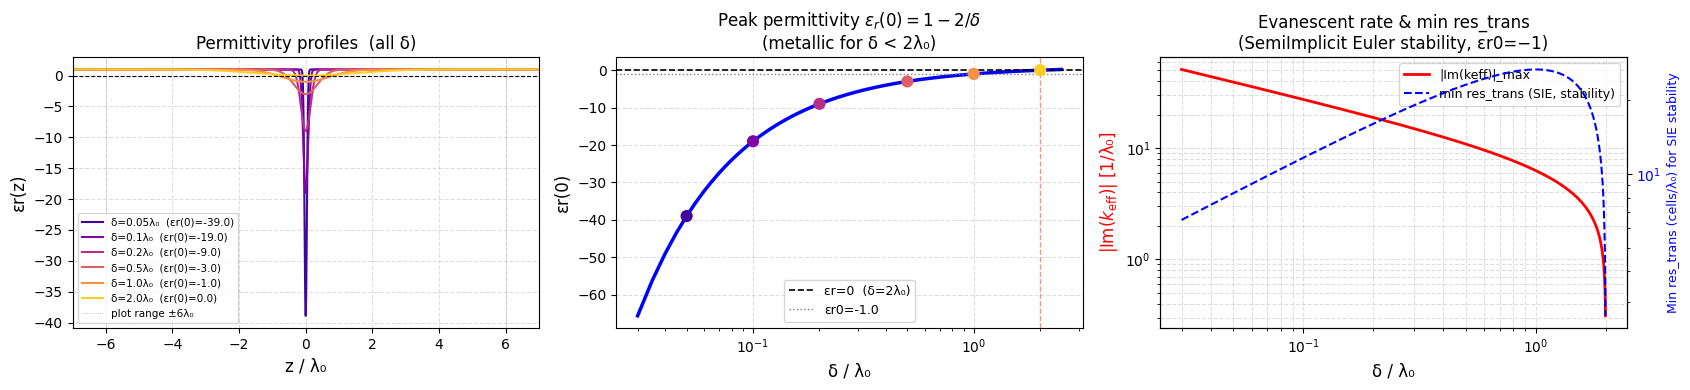

Saved neg_eps_profiles.png


In [9]:
# ── Profile definition ───────────────────────────────────────────────────────
import contextlib, io

eps_r0_neg  = -1.0
lambda0_neg = 1.0
k0_neg      = 2.0 * np.pi / lambda0_neg   # = 2π

def make_eps_gaussian(delta, eps_r0=eps_r0_neg):
    """εr(z) = 1 − (1−εr0)·exp(−(z/δ)²)/δ  — normalized Gaussian dip."""
    coeff = (1.0 - eps_r0) / delta
    def _eps(z):
        return 1.0 - coeff * np.exp(-(z / delta)**2)
    return _eps

def trans_bounds(delta):
    """Transition layer boundaries: z1 = −3δ, z2 = +3δ."""
    return -3.0 * delta, 3.0 * delta

# ── Visualize profiles ───────────────────────────────────────────────────────
deltas_vis = [0.05, 0.1, 0.2, 0.5, 1.0, 2.0]
z_show     = np.linspace(-7, 7, 3000)
cmap_vis   = plt.cm.plasma
colors_vis = cmap_vis(np.linspace(0.1, 0.9, len(deltas_vis)))

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

ax = axes[0]
for d, c in zip(deltas_vis, colors_vis):
    eps_f = make_eps_gaussian(d)
    eps_peak = 1.0 - 2.0 / d
    label = f'δ={d}λ₀  (εr(0)={eps_peak:.1f})'
    ax.plot(z_show, [eps_f(z) for z in z_show], color=c, lw=1.5, label=label)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.axvline(-6, color='gray', lw=0.6, ls=':', alpha=0.6, label='plot range ±6λ₀')
ax.axvline( 6, color='gray', lw=0.6, ls=':', alpha=0.6)
ax.set_xlabel('z / λ₀', fontsize=12); ax.set_ylabel('εr(z)', fontsize=12)
ax.set_title('Permittivity profiles  (all δ)'); ax.legend(fontsize=7.5)
ax.grid(True, ls='--', alpha=0.4); ax.set_xlim(-7, 7)

d_cont        = np.linspace(0.03, 2.5, 500)
eps_peak_cont = 1.0 - 2.0 / d_cont
ax = axes[1]
ax.semilogx(d_cont, eps_peak_cont, 'b-', lw=2.5)
ax.scatter(deltas_vis, [1.0 - 2.0/d for d in deltas_vis], c=colors_vis, s=60, zorder=5)
ax.axhline(0,         color='k',      lw=1.2, ls='--', label='εr=0  (δ=2λ₀)')
ax.axhline(eps_r0_neg, color='gray',  lw=1.0, ls=':',  label=f'εr0={eps_r0_neg}')
ax.axvline(2.0,       color='tomato', lw=1.0, ls='--', alpha=0.7)
ax.set_xlabel('δ / λ₀', fontsize=12); ax.set_ylabel('εr(0)', fontsize=12)
ax.set_title('Peak permittivity $\\varepsilon_r(0) = 1 - 2/\\delta$\n(metallic for δ < 2λ₀)')
ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.4)

# Right: stability threshold expressed as minimum res_trans for SemiImplicitEuler
mask_ev          = eps_peak_cont < 0
d_ev             = d_cont[mask_ev]
keff_imag_peak   = k0_neg * np.sqrt(-eps_peak_cont[mask_ev])
h_stable         = np.sqrt(2.0) / keff_imag_peak
layer_len_ev     = 6.0 * d_ev
# res_trans_min = n_min / layer_len (for lambda0=1):  n_min = layer_len / h_stable
res_trans_min = layer_len_ev / h_stable   # cells per λ₀ needed for stability

ax = axes[2]
ax.loglog(d_ev, keff_imag_peak, 'r-', lw=2, label='|Im(keff)|_max')
ax2r = ax.twinx()
ax2r.loglog(d_ev, res_trans_min, 'b--', lw=1.5,
            label='min res_trans (SIE, stability)')
ax2r.set_ylabel('Min res_trans (cells/λ₀) for SIE stability', fontsize=9, color='b')
ax2r.tick_params(axis='y', labelcolor='b')
ax.set_xlabel('δ / λ₀', fontsize=12)
ax.set_ylabel('|Im($k_\\mathrm{eff}$)| [1/λ₀]', fontsize=12, color='r')
ax.set_title('Evanescent rate & min res_trans\n(SemiImplicit Euler stability, εr0=−1)')
ax.grid(True, which='both', ls='--', alpha=0.4)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2r.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.tight_layout()
plt.savefig('neg_eps_profiles.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved neg_eps_profiles.png')

In [10]:
# ── Stability sweep: all ODE solvers + FEM P2 vs δ ───────────────────────────
deltas_sweep = np.concatenate([
    np.linspace(0.05, 0.19, 8, endpoint=False),
    np.linspace(0.20, 2.00, 12),
])   # 20 δ values

theta_neg, pol_neg = 0.0, 'S'
solvers_neg = list(SOLVER_DICT.keys())
colors_neg  = {'Dopri5':'#1565C0', 'Tsit5':'#2E7D32', 'Heun':'#E65100',
               'KenCarp4':'#6A1B9A', 'SemiImplicitEuler':'#B71C1C'}
markers_neg = {'Dopri5':'o', 'Tsit5':'s', 'Heun':'^', 'KenCarp4':'D', 'SemiImplicitEuler':'v'}


def _res_trans_for_delta(delta, sname, base_res=200.0):
    """
    Required res_trans (cells per λ₀) for each solver and δ.
    layer_len = 6δ, so n_trans = res_trans × 6δ (for lambda0=1).
    - SemiImplicitEuler: stability requires h < sqrt(2)/|Im(keff)|_max.
      Converting: res_trans > |Im(keff)|_max / sqrt(2).  Use 8× safety margin.
    - All others: adaptive; base_res is just the initial-step hint.
    """
    layer_len = 6.0 * delta                # z2 − z1 = 6δ
    eps_peak  = 1.0 - 2.0 / delta
    if sname == 'SemiImplicitEuler' and eps_peak < 0:
        keff_max = k0_neg * np.sqrt(-eps_peak)
        h_lim    = np.sqrt(2.0) / keff_max
        n_stab   = int(np.ceil(layer_len / h_lim))
        return max(base_res, n_stab * 8 / layer_len)
    return base_res


NaN = float('nan')
shape = (len(deltas_sweep),)
data_ode = {s: {'R': np.full(shape, NaN), 'RpT': np.full(shape, NaN),
                'ok': np.zeros(shape, bool)}
            for s in solvers_neg}
data_fem = {'R': np.full(shape, NaN), 'RpT': np.full(shape, NaN),
            'ok': np.zeros(shape, bool)}

print(f'{"δ":>6}  {"εr(0)":>7}  ' +
      '  '.join(f'{s[:5]:>6}' for s in solvers_neg) + '   FEM-P2')
print('-' * 85)

for i, d in enumerate(deltas_sweep):
    z1_d, z2_d = trans_bounds(d)
    eps_f    = make_eps_gaussian(d)
    eps_peak = 1.0 - 2.0 / d
    print(f'{d:6.3f}  {eps_peak:7.2f}  ', end='', flush=True)

    for sname in solvers_neg:
        res      = _res_trans_for_delta(d, sname)
        is_fixed = (sname == 'SemiImplicitEuler')
        solve_kw = {} if is_fixed else {'rtol': 1e-6, 'atol': 1e-6}
        try:
            with contextlib.redirect_stdout(io.StringIO()):
                sv  = HelmholtzSolver1D(eps_f, z1_d, z2_d,
                                        theta_deg=theta_neg, pol=pol_neg,
                                        lambda0=lambda0_neg)
                result = sv.solve_ode(res_trans=res, solver_name=sname,
                                      fixed_step=is_fixed, **solve_kw)
            r_val, t_val = result['r'], result['t']
            R   = abs(r_val)**2
            T   = abs(t_val)**2 * float(np.real(sv.kz2) / np.real(sv.kz1))
            data_ode[sname]['R'][i]   = R
            data_ode[sname]['RpT'][i] = R + T
            data_ode[sname]['ok'][i]  = True
            print(f'{"✓":>6}', end='  ', flush=True)
        except Exception:
            print(f'{"✗":>6}', end='  ', flush=True)

    # FEM P2 — res_trans=200/λ₀ for each δ-layer
    _res_fem = 200.0
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            sv_f  = HelmholtzSolver1D(eps_f, z1_d, z2_d,
                                      theta_deg=theta_neg, pol=pol_neg,
                                      lambda0=lambda0_neg)
            res_f = sv_f.solve_fem(res_trans=_res_fem, order=2)
        r_f, t_f = res_f['r'], res_f['t']
        R_f = abs(r_f)**2
        T_f = abs(t_f)**2 * float(np.real(sv_f.kz2) / np.real(sv_f.kz1))
        data_fem['R'][i]   = R_f
        data_fem['RpT'][i] = R_f + T_f
        data_fem['ok'][i]  = True
        print('✓', flush=True)
    except Exception as e:
        print(f'✗ ({str(e)[:40]})', flush=True)

print('\nSweep complete.')

     δ    εr(0)   Dopri   Tsit5    Heun   KenCa   SemiI   FEM-P2
-------------------------------------------------------------------------------------
 0.050   -39.00       ✓       ✓       ✓       ✓       ✓  ✓
 0.068   -28.63       ✓       ✓       ✓       ✓       ✓  ✓
 0.085   -22.53       ✓       ✓       ✓       ✓       ✓  ✓
 0.103   -18.51       ✓       ✓       ✓       ✓       ✓  ✓
 0.120   -15.67       ✓       ✓       ✓       ✓       ✓  ✓
 0.138   -13.55       ✓       ✓       ✓       ✓       ✓  ✓
 0.155   -11.90       ✓       ✓       ✓       ✓       ✓  ✓
 0.173   -10.59       ✓       ✓       ✓       ✓       ✓  ✓
 0.200    -9.00       ✓       ✓       ✓       ✓       ✓  ✓
 0.364    -4.50       ✓       ✓       ✓       ✓       ✓  ✓
 0.527    -2.79       ✓       ✓       ✓       ✓       ✓  ✓
 0.691    -1.89       ✓       ✓       ✓       ✓       ✓  ✓
 0.855    -1.34       ✓       ✓       ✓       ✓       ✓  ✓
 1.018    -0.96       ✓       ✓       ✓       ✓       ✓  ✓
 1.182    -0.69       ✓

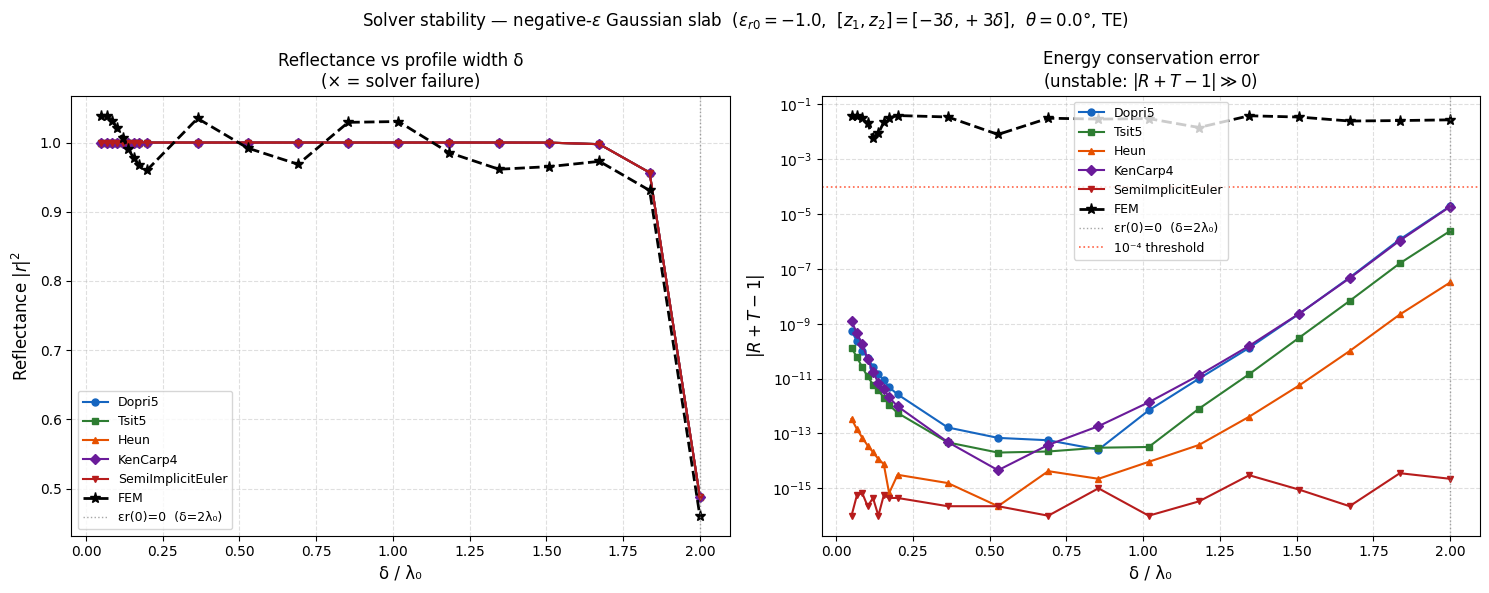

Saved neg_eps_stability.png


In [11]:
# ── Stability plots: Reflectance and Energy error vs δ ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    r'Solver stability — negative-$\varepsilon$ Gaussian slab  '
    r'($\varepsilon_{r0}=' + f'{eps_r0_neg}' + r'$,  $[z_1,z_2]=[-3\delta,+3\delta]$,  '
    f'$\\theta={theta_neg}°$, TE)',
    fontsize=12)

ax_R, ax_E = axes

# ── Left: reflectance |r|² vs δ ──────────────────────────────────────────────
for sname in solvers_neg:
    ok = data_ode[sname]['ok']
    R  = data_ode[sname]['R']
    if ok.any():
        ax_R.plot(deltas_sweep[ok], R[ok],
                  color=colors_neg[sname], marker=markers_neg[sname],
                  ms=5, lw=1.5, label=sname)
    if (~ok).any():
        ax_R.scatter(deltas_sweep[~ok], np.zeros((~ok).sum()),
                     color=colors_neg[sname], marker='x', s=80, zorder=6)

ok_f = data_fem['ok']
if ok_f.any():
    ax_R.plot(deltas_sweep[ok_f], data_fem['R'][ok_f],
              'k--', marker='*', ms=8, lw=2.0, label='FEM')

ax_R.axvline(2.0, color='gray', lw=1.0, ls=':', alpha=0.7, label='εr(0)=0  (δ=2λ₀)')
ax_R.set_xlabel('δ / λ₀', fontsize=12)
ax_R.set_ylabel('Reflectance $|r|^2$', fontsize=12)
ax_R.set_title('Reflectance vs profile width δ\n(× = solver failure)')
ax_R.legend(fontsize=9); ax_R.grid(True, ls='--', alpha=0.4)

# ── Right: energy error |R+T−1| vs δ (stability proxy) ──────────────────────
for sname in solvers_neg:
    ok  = data_ode[sname]['ok']
    err = np.abs(data_ode[sname]['RpT'] - 1.0)
    if ok.any():
        ax_E.semilogy(deltas_sweep[ok], np.maximum(err[ok], 1e-16),
                      color=colors_neg[sname], marker=markers_neg[sname],
                      ms=5, lw=1.5, label=sname)

ok_f = data_fem['ok']
if ok_f.any():
    err_f = np.abs(data_fem['RpT'] - 1.0)
    ax_E.semilogy(deltas_sweep[ok_f], np.maximum(err_f[ok_f], 1e-16),
                  'k--', marker='*', ms=8, lw=2.0, label='FEM')

ax_E.axvline(2.0, color='gray', lw=1.0, ls=':', alpha=0.7, label='εr(0)=0  (δ=2λ₀)')
ax_E.axhline(1e-4, color='tomato', ls=':', lw=1.2, label='10⁻⁴ threshold')
ax_E.set_xlabel('δ / λ₀', fontsize=12)
ax_E.set_ylabel('$|R + T - 1|$', fontsize=12)
ax_E.set_title('Energy conservation error\n(unstable: $|R+T-1| \\gg 0$)')
ax_E.legend(fontsize=9); ax_E.grid(True, which='both', ls='--', alpha=0.4)

plt.tight_layout()
plt.savefig('neg_eps_stability.png', dpi=120)
plt.show()
print('Saved neg_eps_stability.png')

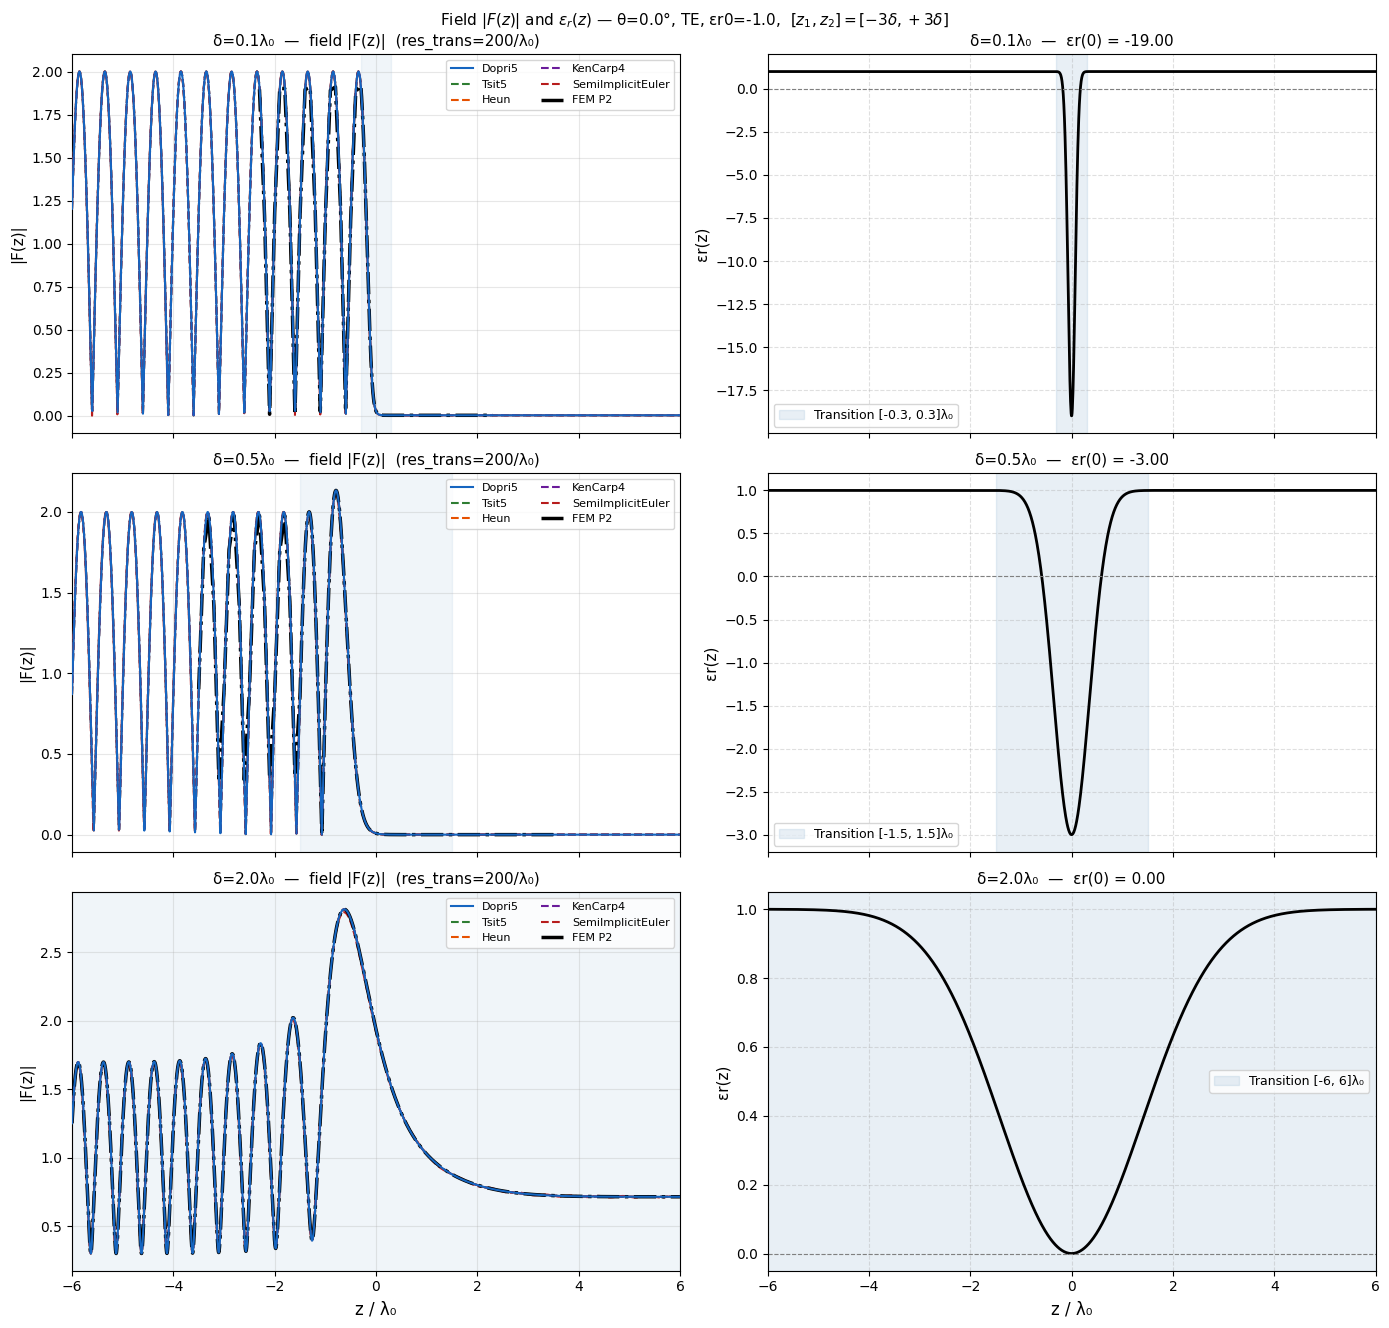

Saved neg_eps_fields.png


In [12]:
# ── Field profiles for select δ: compare all ODE solvers + FEM P2 ────────────
deltas_field = [0.1, 0.5, 2.0]
N_RES_FIELD  = 200.0    # res_trans per λ₀ for field profiles
PLOT_LO, PLOT_HI = -6.0, 6.0

fig, axes_f = plt.subplots(len(deltas_field), 2,
                            figsize=(14, 4.5 * len(deltas_field)),
                            sharex='col')
fig.suptitle(
    r'Field $|F(z)|$ and $\varepsilon_r(z)$ — '
    f'θ={theta_neg}°, TE, εr0={eps_r0_neg},  '
    r'$[z_1,z_2]=[-3\delta,+3\delta]$',
    fontsize=11)

z_eps_plot = np.linspace(PLOT_LO, PLOT_HI, 2000)

for row, d in enumerate(deltas_field):
    z1_d, z2_d   = trans_bounds(d)
    eps_f        = make_eps_gaussian(d)
    eps_peak     = 1.0 - 2.0 / d
    L_ext_ode    = max(PLOT_HI - z2_d, 0.5)

    ax_field = axes_f[row, 0]
    ax_eps   = axes_f[row, 1]

    # ── ε profile ────────────────────────────────────────────────────────────
    eps_vals_plot = np.array([eps_f(z) for z in z_eps_plot])
    ax_eps.plot(z_eps_plot, eps_vals_plot, 'k-', lw=2)
    ax_eps.axvspan(z1_d, z2_d, color='steelblue', alpha=0.12,
                   label=f'Transition [{z1_d:.2g}, {z2_d:.2g}]λ₀')
    ax_eps.axhline(0, color='gray', lw=0.8, ls='--')
    ax_eps.set_xlim(PLOT_LO, PLOT_HI)
    ax_eps.set_ylabel('εr(z)', fontsize=11)
    ax_eps.set_title(f'δ={d}λ₀  —  εr(0) = {eps_peak:.2f}', fontsize=11)
    ax_eps.legend(fontsize=9); ax_eps.grid(True, ls='--', alpha=0.4)

    # ── ODE solvers ───────────────────────────────────────────────────────────
    for sname in solvers_neg:
        res      = _res_trans_for_delta(d, sname, base_res=N_RES_FIELD)
        is_fixed = (sname == 'SemiImplicitEuler')
        solve_kw = {} if is_fixed else {'rtol': 1e-6, 'atol': 1e-6}
        try:
            with contextlib.redirect_stdout(io.StringIO()):
                sv  = HelmholtzSolver1D(eps_f, z1_d, z2_d,
                                        theta_deg=theta_neg, pol=pol_neg,
                                        lambda0=lambda0_neg)
                result = sv.solve_ode(res_trans=res, L_ext_factor=L_ext_ode,
                                      solver_name=sname, fixed_step=is_fixed,
                                      **solve_kw)
            z_res, F_res = result['z'], result['field']
            mask = (z_res >= PLOT_LO) & (z_res <= PLOT_HI)
            ls   = '-'  if sname == 'Dopri5' else '--'
            zord = 5    if sname == 'Dopri5' else 3
            ax_field.plot(z_res[mask], np.abs(F_res[mask]),
                          color=colors_neg[sname], lw=1.5, ls=ls,
                          label=sname, zorder=zord)
        except Exception:
            pass

    # ── FEM P2 (L_ext=2λ₀, accurate Robin BCs) ───────────────────────────────
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            sv_f  = HelmholtzSolver1D(eps_f, z1_d, z2_d,
                                      theta_deg=theta_neg, pol=pol_neg,
                                      lambda0=lambda0_neg)
            res_f = sv_f.solve_fem(res_trans=N_RES_FIELD, order=2)
        z_f, F_f = res_f['z'], res_f['field']
        mask_f   = (z_f >= PLOT_LO) & (z_f <= PLOT_HI)
        ax_field.plot(z_f[mask_f], np.abs(F_f[mask_f]),
                      color='k', lw=2.5, ls='-.', label='FEM P2', zorder=4)
    except Exception as e:
        print(f'FEM δ={d}: {e}')

    ax_field.axvspan(z1_d, z2_d, color='steelblue', alpha=0.08)
    ax_field.set_xlim(PLOT_LO, PLOT_HI)
    ax_field.set_ylabel('|F(z)|', fontsize=11)
    ax_field.set_title(f'δ={d}λ₀  —  field |F(z)|  (res_trans={N_RES_FIELD:.0f}/λ₀)', fontsize=11)
    ax_field.legend(fontsize=8, ncol=2); ax_field.grid(True, alpha=0.3)

    if row == len(deltas_field) - 1:
        ax_field.set_xlabel('z / λ₀', fontsize=12)
        ax_eps.set_xlabel('z / λ₀', fontsize=12)

plt.tight_layout()
plt.savefig('neg_eps_fields.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved neg_eps_fields.png')